In [406]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [407]:
pd.set_option("display.max_columns", None)
df = pd.read_csv("imdb_top_1000.csv")
df.head(5)

,Poster_Link,Series_Title,Released_Year,Certificate,Runtime,Genre,IMDB_Rating,Overview,Meta_score,Director,Star1,Star2,Star3,Star4,No_of_Votes,Gross
0,https://m.media-amazon.com/images/M/MV5BMDFkYT...,The Shawshank Redemption,1994,A,142 min,Drama,9.3,Two imprisoned men bond over a number of years...,80.0,Frank Darabont,Tim Robbins,Morgan Freeman,Bob Gunton,William Sadler,2343110,"28,341,469"
1,https://m.media-amazon.com/images/M/MV5BM2MyNj...,The Godfather,1972,A,175 min,"Crime, Drama",9.2,An organized crime dynasty's aging patriarch t...,100.0,Francis Ford Coppola,Marlon Brando,Al Pacino,James Caan,Diane Keaton,1620367,"134,966,411"
2,https://m.media-amazon.com/images/M/MV5BMTMxNT...,The Dark Knight,2008,UA,152 min,"Action, Crime, Drama",9.0,When the menace known as the Joker wreaks havo...,84.0,Christopher Nolan,Christian Bale,Heath Ledger,Aaron Eckhart,Michael Caine,2303232,"534,858,444"
3,https://m.media-amazon.com/images/M/MV5BMWMwMG...,The Godfather: Part II,1974,A,202 min,"Crime, Drama",9.0,The early life and career of Vito Corleone in ...,90.0,Francis Ford Coppola,Al Pacino,Robert De Niro,Robert Duvall,Diane Keaton,1129952,"57,300,000"
4,https://m.media-amazon.com/images/M/MV5BMWU4N2...,12 Angry Men,1957,U,96 min,"Crime, Drama",9.0,A jury holdout attempts to prevent a miscarria...,96.0,Sidney Lumet,Henry Fonda,Lee J. Cobb,Martin Balsam,John Fiedler,689845,"4,360,000"


In [408]:
df.dtypes

,0
Poster_Link,object
Series_Title,object
Released_Year,object
Certificate,object
Runtime,object
Genre,object
IMDB_Rating,float64
Overview,object
Meta_score,float64
Director,object


In [409]:
df.isna().sum()

,0
Poster_Link,0
Series_Title,0
Released_Year,0
Certificate,101
Runtime,0
Genre,0
IMDB_Rating,0
Overview,0
Meta_score,157
Director,0


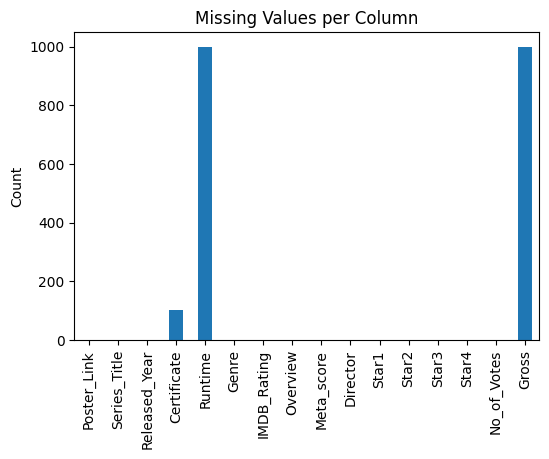

In [426]:
plt.figure(figsize=(6,4))
df.isnull().sum().plot(kind='bar')
plt.title("Missing Values per Column")
plt.ylabel("Count")
plt.show()

In [411]:
df.duplicated().sum()

np.int64(0)

The dataset contains missing values in Released_Year, Certificate, Meta_score, and Gross columns. No duplicate rows were found. Numerical columns are already correctly formatted.

In [412]:
# numerical columns
df['Meta_score'] = df['Meta_score'].fillna(df['Meta_score'].median())

In [413]:
df.isna().sum()

,0
Poster_Link,0
Series_Title,0
Released_Year,0
Certificate,101
Runtime,0
Genre,0
IMDB_Rating,0
Overview,0
Meta_score,0
Director,0


Mode was used for numerical data since it preserves the most frequent category.

In [414]:
cols = ['IMDB_Rating','Meta_score','Gross','Runtime']

for c in cols:
    df[c] = pd.to_numeric(df[c], errors='coerce')

print(df[cols].dtypes)

IMDB_Rating    float64
Meta_score     float64
Gross          float64
Runtime        float64
dtype: object


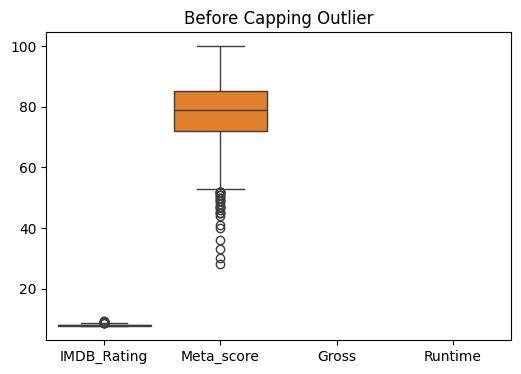

In [415]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df[['IMDB_Rating','Meta_score','Gross','Runtime']])
plt.title("Before Capping Outlier")
plt.show()

In [416]:
from sklearn.base import OutlierMixin
def remove_outliers(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    return data[(data[column] >= lower) & (data[column] <= upper)]

In [417]:
df_capped = df.copy()
for col in cols:
    lower = df[col].quantile(0.05)
    upper = df[col].quantile(0.95)
    df_capped[col] = df_capped[col].clip(lower=lower, upper=upper)
df.shape

(1000, 16)

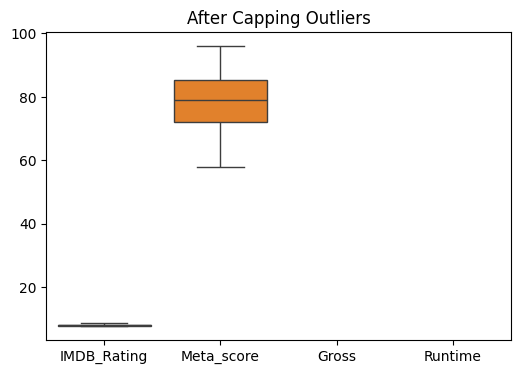

In [418]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df_capped[cols])
plt.title("After Capping Outliers")
plt.show()

Outliers were detected using the Interquartile Range (IQR) method and removed to improve model reliability.

In [419]:
df[['IMDB_Rating','Meta_score','Gross','Runtime']].head()

,IMDB_Rating,Meta_score,Gross,Runtime
0,9.3,80.0,NaN,NaN
1,9.2,100.0,NaN,NaN
2,9.0,84.0,NaN,NaN
3,9.0,90.0,NaN,NaN
4,9.0,96.0,NaN,NaN


In [420]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df_scaled = df[['IMDB_Rating','Meta_score','Gross','Runtime']].copy()

df_scaled[['IMDB_Rating','Meta_score','Gross','Runtime']] = scaler.fit_transform(df_scaled)

df_scaled.head()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/_array_api.py:776: RuntimeWarning: All-NaN slice encountered
  return xp.asarray(numpy.nanmin(X, axis=axis))
/usr/local/lib/python3.12/dist-packages/sklearn/utils/_array_api.py:793: RuntimeWarning: All-NaN slice encountered
  return xp.asarray(numpy.nanmax(X, axis=axis))


,IMDB_Rating,Meta_score,Gross,Runtime
0,1.000000,0.722222,NaN,NaN
1,0.941176,1.000000,NaN,NaN
2,0.823529,0.777778,NaN,NaN
3,0.823529,0.861111,NaN,NaN
4,0.823529,0.944444,NaN,NaN


In [421]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_standardized = df[['IMDB_Rating','Meta_score','Gross','Runtime']].copy()

df_standardized[['IMDB_Rating','Meta_score','Gross','Runtime']] = scaler.fit_transform(df_standardized)

df_standardized.head()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1101: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1106: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1126: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count


,IMDB_Rating,Meta_score,Gross,Runtime
0,4.905332,0.164312,NaN,NaN
1,4.542162,1.924482,NaN,NaN
2,3.815823,0.516346,NaN,NaN
3,3.815823,1.044397,NaN,NaN
4,3.815823,1.572448,NaN,NaN


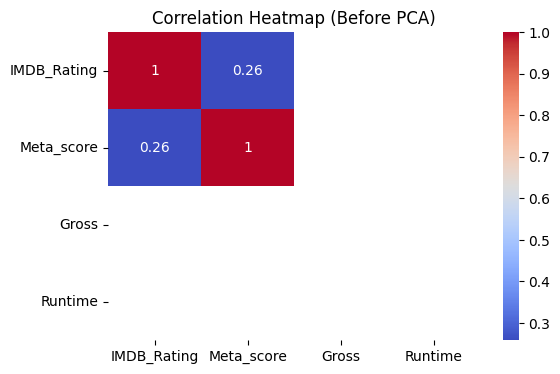

In [425]:
plt.figure(figsize=(6,4))
sns.heatmap(df_standardized[['IMDB_Rating','Meta_score','Gross','Runtime']].corr(),
            annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap (Before PCA)")
plt.show()